In [101]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

In [102]:
import jax
import jax.numpy as jnp
from flax import linen as nn
import optax
import copy

from typing import Callable

from functools import partial

import tensorflow as tf
from pyDOE import lhs
import numpy as np
import matplotlib.pyplot as plt

from scipy.integrate import odeint
from scipy.special import erf

from jax import config
config.update("jax_enable_x64", True)

In [103]:
t0, tfinal = 0.0, 0.5

In [104]:
m1 = 1.0
m2 = 1.0
l1 = 1.0
l2 = 1.0
grav = 9.81

In [105]:
class Normalize(nn.Module):
  xmin: float
  xmax: float

  @nn.compact
  def __call__(self, x):
    return 2.0*(x-self.xmin)/(self.xmax - self.xmin) - 1.0

In [106]:
class HardConstraint(nn.Module):
  t0: float
  tfinal: float
  u0: float

  @nn.compact
  def __call__(self, inputs):
    t, nn = inputs
    return self.u0 + (t-self.t0)/(self.tfinal-self.t0)*nn

In [107]:
class CombineBranches(nn.Module):
  @nn.compact
  def __call__(self, inp1, inp2):
    mult = jnp.sum(inp1*inp2, axis=1)
    out = jnp.reshape(mult, (-1,1))
    return out

In [108]:
class MLP(nn.Module):

  layers: int
  units: int

  @nn.compact
  def __call__(self, inp):
    b = inp
    for i in range(self.layers-1):
      b = nn.Dense(self.units)(b)
      b = nn.tanh(b)
    out = nn.Dense(4*self.units)(b)
    return out

In [109]:
class DeepONet(nn.Module):

  t0: float
  tfinal: float
  layers: int
  units: int

  @nn.compact
  def __call__(self, t, u):

    if u.ndim == 1:
      u = jnp.reshape(u, (1,-1))

    x1_0 = u[:,:1]
    x2_0 = u[:,1:2]
    y1_0 = u[:,2:3]
    y2_0 = u[:,3:]

    t = jnp.reshape(t, (-1,1))

    b = Normalize(self.t0, self.tfinal)(t)

    trunk_net = MLP(self.layers, self.units)(b)
    branch_net = MLP(self.layers, self.units)(u)

    trunk_x1 = trunk_net[:,:self.units]
    trunk_x2 = trunk_net[:,self.units:2*self.units]
    trunk_y1 = trunk_net[:,2*self.units:3*self.units]
    trunk_y2 = trunk_net[:,3*self.units:]

    branch_x1 = branch_net[:,:self.units]
    branch_x2 = branch_net[:,self.units:2*self.units]
    branch_y1 = branch_net[:,2*self.units:3*self.units]
    branch_y2 = branch_net[:,3*self.units:]

    x1 = CombineBranches()(trunk_x1, branch_x1)
    x2 = CombineBranches()(trunk_x2, branch_x2)
    y1 = CombineBranches()(trunk_y1, branch_y1)
    y2 = CombineBranches()(trunk_y2, branch_y2)

    x1 = HardConstraint(self.t0, self.tfinal, x1_0)([t, x1])
    x2 = HardConstraint(self.t0, self.tfinal, x2_0)([t, x2])
    y1 = HardConstraint(self.t0, self.tfinal, y1_0)([t, y1])
    y2 = HardConstraint(self.t0, self.tfinal, y2_0)([t, y2])

    x1 = jnp.reshape(x1, (-1,))
    x2 = jnp.reshape(x2, (-1,))
    y1 = jnp.reshape(y1, (-1,))
    y2 = jnp.reshape(y2, (-1,))

    return x1, x2, y1, y2

In [110]:
deeponet = DeepONet(t0, tfinal, layers=4, units=40)

params = deeponet.init(jax.random.PRNGKey(0), jnp.ones((10,)), jnp.ones((10,4)))

In [111]:
def defineCollocationPoints(t_bdry, N=100):

  ode_points = t_bdry[0] + (t_bdry[1] - t_bdry[0])*lhs(1, N)

  xs = np.random.uniform(-np.pi/6, np.pi/6, size=(N, 2))
  ys = np.random.uniform(-np.pi/6, np.pi/6, size=(N, 2))

  zsensors = np.column_stack((xs, ys))

  return (ode_points, zsensors)

In [112]:
(de_points, zsensors) = defineCollocationPoints([t0, tfinal], 5000)

In [113]:
@partial(jax.jit, static_argnums=(2,))
def w_model(t, z, component, params):
  return deeponet.apply(params, t, z)[component][0]

@partial(jax.jit, static_argnums=(2,))
def w(t, z, component, params):
  return jax.vmap(w_model, [0, 0, None, None])(t, z, component, params)

@partial(jax.jit, static_argnums=(2,))
def w_t(t, z, component, params):
  return jax.vmap(jax.grad(w_model, 0), [0, 0, None, None])(t, z, component, params)

@jax.jit
def loss(params, t, z):

    x1 = w(t, z, 0, params)
    x2 = w(t, z, 1, params)
    y1 = w(t, z, 2, params)
    y2 = w(t, z, 3, params)
    
    x1_t = w_t(t, z, 0, params)
    x2_t = w_t(t, z, 1, params)
    y1_t = w_t(t, z, 2, params)
    y2_t = w_t(t, z, 3, params)
    
    
    A = l1*l2*(m1 + m2*(jnp.sin(x1 - x2)**2))
    h1 = (y1*y2*jnp.sin(x1 - x2))/A
    h2 = (m2*(l2**2)*(y1**2) + (m1 + m2)*(l1**2)*(y2**2) - 2*m2*l1*l2*y1*y2*jnp.cos(x1 - x2))/(2*A**2)
    
    x1_t_loss = x1_t - (l2*y1 - l1*y2*jnp.cos(x1 - x2))/(l1*A)
    x2_t_loss = x2_t - (-m2*l2*y1*jnp.cos(x1 - x2) + l1*(m1 + m2)*y2)/(m2*l2*A)
    y1_t_loss = y1_t - (-(m1 + m2)*grav*l1*jnp.sin(x1) - h1 + h2*jnp.sin(2*(x1 - x2)))
    y2_t_loss = y2_t - (-m2*grav*l2*jnp.sin(x2) + h1 - h2*jnp.sin(2*(x1 - x2)))

    diff_loss = jnp.mean(x1_t_loss**2 + x2_t_loss**2 + y1_t_loss**2 + y2_t_loss**2)

    return diff_loss

@jax.jit
def train_step(params, pdes, z):
  t = pdes[:,0]
  return jax.value_and_grad(loss)(params, t, z)

@partial(jax.jit, static_argnums=(3,))
def optimize(grads, opt_state, params, optimizer_update):
  updates, opt_state = optimizer_update(grads, opt_state, params)
  params = optax.apply_updates(params, updates)
  return params, opt_state

In [114]:
def train_network(params, des, zsensor, epochs=100):

  N = de_points.shape[0]

  nr_batches = 10
  batch_size = len(des)//nr_batches

  lr = 1e-3
  optimizer = optax.adam(lr)
  opt_state = optimizer.init(params)

  ds_z = tf.data.Dataset.from_tensor_slices(zsensors)
  ds_de = tf.data.Dataset.from_tensor_slices(des)

  ds = tf.data.Dataset.zip((ds_de, ds_z))
  ds = ds.shuffle(N).batch(batch_size)

  epoch_loss = np.zeros(epochs)

  for i in range(epochs):

    for (des_batch, z_batch) in ds:

      loss, grads = train_step(params, des_batch.numpy(), z_batch.numpy())
      params, opt_state = optimize(grads, opt_state, params, optimizer.update)

      epoch_loss[i] += loss

    epoch_loss[i] /= batch_size

    if i % 100 == 0:
      print(f'Loss in epoch {i}: {epoch_loss[i]}')

  return params, epoch_loss

In [115]:
epochs = 300
params, loss = train_network(params, de_points, zsensors, epochs)

Loss in epoch 0: 0.6406377962345777
Loss in epoch 100: 0.0018641323323357632
Loss in epoch 200: 0.0014530109302674735


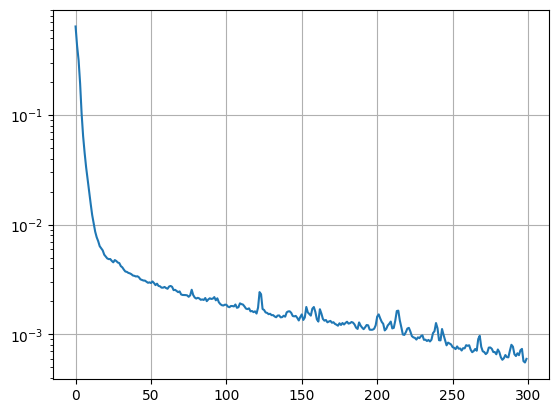

In [116]:
plt.semilogy(loss)
plt.grid()

In [117]:
n = 500
t = np.linspace(t0, tfinal, n)

init_data = np.random.uniform(-np.pi/6, np.pi/6, size=(4,))
z = np.repeat(np.expand_dims(init_data, axis=0), len(t), axis=0)

In [118]:
x1 = jax.vmap(w_model, [0, 0, None, None])(t, z, 0, params)
x2 = jax.vmap(w_model, [0, 0, None, None])(t, z, 1, params)
y1 = jax.vmap(w_model, [0, 0, None, None])(t, z, 2, params)
y2 = jax.vmap(w_model, [0, 0, None, None])(t, z, 3, params)

In [119]:
def doublePendulum(w, t):
    
    x1, x2, y1, y2 = w
    
    A = l1*l2*(m1 + m2*(jnp.sin(x1 - x2)**2))
    h1 = (y1*y2*jnp.sin(x1 - x2))/A
    h2 = (m2*(l2**2)*(y1**2) + (m1 + m2)*(l1**2)*(y2**2) - 2*m2*l1*l2*y1*y2*jnp.cos(x1 - x2))/(2*A**2)

    x1_t = (l2*y1 - l1*y2*jnp.cos(x1 - x2))/(l1*A)
    x2_t = (-m2*l2*y1*jnp.cos(x1 - x2) + l1*(m1 + m2)*y2)/(m2*l2*A)
    y1_t = -(m1 + m2)*grav*l1*jnp.sin(x1) - h1 + h2*jnp.sin(2*(x1 - x2))
    y2_t = -m2*grav*l2*jnp.sin(x2) + h1 - h2*jnp.sin(2*(x1 - x2))

    dwdt = [x1_t, x2_t, y1_t, y2_t]

    return dwdt

sol_rk = odeint(doublePendulum, init_data, t)
x1rk, x2rk, y1rk, y2rk = sol_rk[:,0], sol_rk[:,1], sol_rk[:,2], sol_rk[:,3]

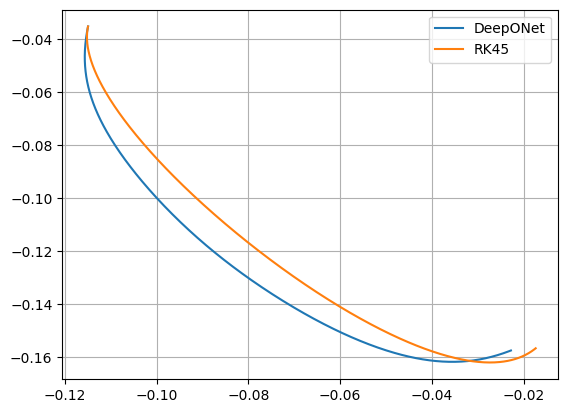

In [120]:
plt.plot(x1, x2)
plt.plot(x1rk, x2rk)

plt.grid()
plt.legend(['DeepONet','RK45'])

Text(0.5, 1.0, 'Solution time series')

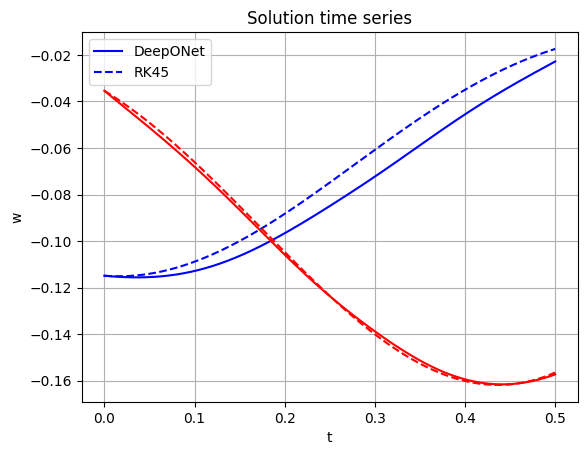

In [121]:
plt.plot(t, x1,'b')
plt.plot(t, x1rk,'b--')

plt.plot(t, x2, 'r')
plt.plot(t, x2rk, 'r--')

plt.legend(['DeepONet', 'RK45'])
plt.grid()
plt.xlabel('t')
plt.ylabel('w')
plt.title('Solution time series')

Text(0.5, 1.0, 'Hamiltonian l2-error: 0.40833')

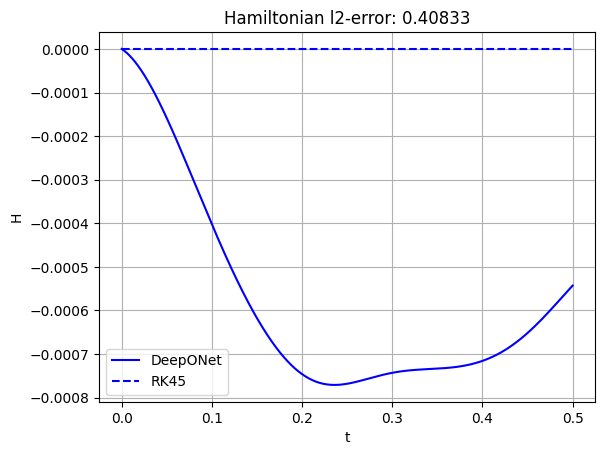

In [122]:
Hs = (m2*l2**2*y1**2 + (m1+m2)*l1**2*y2**2 - 2*m2*l1*l2*y1*y2*np.cos(x1-x2))/(2*m2*l1**2*l2**2*(m1+m2*np.sin(x1-x2)**2))-(m1+m2)*grav*l1*np.cos(x1)-m2*grav*l2*np.cos(x2)
H_rk = (m2*l2**2*y1rk**2 + (m1+m2)*l1**2*y2rk**2 - 2*m2*l1*l2*y1rk*y2rk*np.cos(x1rk-x2rk))/(2*m2*l1**2*l2**2*(m1+m2*np.sin(x1rk-x2rk)**2))-(m1+m2)*grav*l1*np.cos(x1rk)-m2*grav*l2*np.cos(x2rk)

plt.plot(t, (Hs-Hs[0])/Hs[0],'b')
plt.plot(t, (H_rk-H_rk[0])/H_rk[0],'b--')

plt.legend(['DeepONet', 'RK45'])
plt.grid()
plt.xlabel('t')
plt.ylabel('H')
plt.title(f'Hamiltonian l2-error: {np.linalg.norm((Hs-Hs[0])):2.5f}')

In [266]:
#@jax.jit
def deriv_D(x, H_0) :

    x1 = x[0]
    x2 = x[1]
    y1 = x[2]
    y2 = x[3]

    A = l1*l2*(m1 + m2*(jnp.sin(x1 - x2)**2))
    h1 = (y1*y2*jnp.sin(x1 - x2))/A
    h2 = (m2*(l2**2)*(y1**2) + (m1 + m2)*(l1**2)*(y2**2) - 2*m2*l1*l2*y1*y2*jnp.cos(x1 - x2))/(2*A**2)

    H = (m2*l2**2*y1**2 + (m1+m2)*l1**2*y2**2 - 2*m2*l1*l2*y1*y2*jnp.cos(x1-x2))/(2*m2*l1**2*l2**2*(m1+m2*jnp.sin(x1-x2)**2))-(m1+m2)*grav*l1*jnp.cos(x1)-m2*grav*l2*jnp.cos(x2)

    dH_dx1 = (m1 + m2)*grav*l1*jnp.sin(x1) + h1 - h2*jnp.sin(2*(x1 - x2))
    dH_dx2 = m2*grav*l2*jnp.sin(x2) - h1 + h2*jnp.sin(2*(x1 - x2))
    dH_dy1 = (l2*y1 - l1*y2*jnp.cos(x1-x2))/(l1*A)
    dH_dy2 = (l1*(m1+m2)*y2 - m2*l2*y1*jnp.cos(x1-x2))/(m2*l2*A)

    dD_dx1 = 2*(H_0 - H)*dH_dx1
    dD_dx2 = 2*(H_0 - H)*dH_dx2
    dD_dy1 = 2*(H_0 - H)*dH_dy1
    dD_dy2 = 2*(H_0 - H)*dH_dy2
    
    deriv_D = jnp.array([dD_dx1, dD_dx2, dD_dy1, dD_dy2])
    deriv_D = jnp.reshape(deriv_D, (-1, 1))

    return deriv_D

In [267]:
#@jax.jit
def func_D(x, H_0) :
 
    x1 = x[0]
    x2 = x[1]
    y1 = x[2]
    y2 = x[3]

    # print(x.shape)
    # print(x1.shape, x2.shape, y1.shape, y2.shape)
    # input()
   
    H = (m2*l2**2*y1**2 + (m1+m2)*l1**2*y2**2 - 2*m2*l1*l2*y1*y2*jnp.cos(x1-x2))/(2*m2*l1**2*l2**2*(m1+m2*jnp.sin(x1-x2)**2))-(m1+m2)*grav*l1*jnp.cos(x1)-m2*grav*l2*jnp.cos(x2)

    D = (H_0 - H)**2
    
    return D

In [268]:
#@jax.jit
def find_rec(x):
    
    x = x + jnp.finfo(jnp.float64).eps
    return 1/x

In [269]:
#@jax.jit
def wolfe_conds(args):

    alpha, curr_x, curr_f, curr_grad, next_x, next_f, next_grad, p, c1, c2, H_0, iter = args

    cond_1 = next_f - curr_f - c1*alpha*(curr_grad.T@p)
    cond_2 = next_grad.T@p - c2*(curr_grad.T@p)
    
    cond_1_bool = jax.lax.cond(cond_1[0][0] > 0.0 , lambda x: True, lambda x: False, None)
    cond_2_bool = jax.lax.cond(cond_2[0][0] < 0.0 , lambda x: True, lambda x: False, None)
    cond_3_bool = jax.lax.cond(alpha >= 1e-2 , lambda x: True, lambda x: False, None)

    wolfe_bool = jnp.logical_or(cond_1_bool, cond_2_bool)
    final_bool = jnp.logical_and(wolfe_bool, cond_3_bool)
    # final_bool = wolfe_bool
    
    return final_bool

In [270]:
#@jax.jit
def update_alpha(args) :

    alpha, curr_x, curr_f, curr_grad, next_x, next_f, next_grad, p, c1, c2, H_0, iter = args

    alpha = alpha*0.1
    iter = iter + 1
        
    next_x = curr_x + alpha*p
    next_f = func_D(next_x, H_0)
    next_grad = deriv_D(next_x, H_0) 
   
    return (alpha, curr_x, curr_f, curr_grad, next_x, next_f, next_grad, p, c1, c2, H_0, iter)

In [271]:
#@jax.jit
def BFGS(x, H_0) :

    x = jnp.reshape(x, (-1,1))
    H_0 = jnp.reshape(H_0, (-1,1))

    x_0 = jnp.copy(x)
    
    iter = 0
    init_iter = 0
    alpha = 1.0
    c1 = 1e-4
    c2 = 0.9
    I_3 = jnp.identity(4, dtype = jnp.float64)
    B_0_inv = jnp.identity(4, dtype = jnp.float64)

    D_0 = func_D(x, H_0)
    gradD_0 = deriv_D(x, H_0)

    print(x_0.shape, B_0_inv.shape, gradD_0.shape)
    input()

    p = -1.0*alpha*(B_0_inv@gradD_0)

    next_x = x_0 + alpha*p
    next_D = func_D(next_x, H_0)
    next_gradD = deriv_D(next_x, H_0)


    # print(next_x.shape, next_D.shape, next_gradD.shape, p.shape)
    # input()

    init_args = (alpha, x_0, D_0, gradD_0, next_x, next_D, next_gradD, p, c1, c2, H_0, init_iter)
    
    step, _, _, _, _, _, _, _, _, _, _, _ = jax.lax.while_loop(wolfe_conds, update_alpha, init_args)

    x_1 = x_0 - step*(B_0_inv@gradD_0)

    while iter < 10:

        delta_x = x_1 - x_0

        D_1 = func_D(x_1, H_0)
        gradD_1 = deriv_D(x_1, H_0)

        y = gradD_1 - gradD_0       

        y_T_delta_x = y.T@delta_x
        y_T_delta_x_rec = find_rec(y_T_delta_x)
        
        B_1_inv = ((I_3 - (y_T_delta_x_rec*(delta_x@y.T)))@B_0_inv@(I_3 - (y_T_delta_x_rec*(y@delta_x.T)))) + (y_T_delta_x_rec*(delta_x@delta_x.T))   
        p = -1.0*alpha*(B_1_inv@gradD_1)
        
        next_x = x_1 + alpha*p
        next_D = func_D(next_x, H_0)
        next_gradD = deriv_D(next_x, H_0) 
                  
        init_args = (alpha, x_1, D_1, gradD_1, next_x, next_D, next_gradD, p, c1, c2, H_0, init_iter)

        step, _, _, _, _, _, _, _, _, _, _, _ = jax.lax.while_loop(wolfe_conds, update_alpha, init_args)
        # print(step)

        x_next = x_1 - step*(B_1_inv@gradD_1)

        x_0 = x_1
        x_1 = x_next

        D_0 = D_1
        gradD_0 = gradD_1

        B_0_inv = B_1_inv
        
        iter = iter + 1


    return x_1

In [272]:
#@jax.jit
def find_min_H(x, H_0) :

    return jax.vmap(BFGS, (0, 0), 0)(x, H_0)

In [273]:
class ClosestPoint(nn.Module):
    
    @nn.compact
    def __call__(self, inputs):

        x = inputs[0]
        H_0 = inputs[1]
        
        z_min = find_min_H(x, H_0)
    
        return z_min

In [274]:
class CDeepONet(nn.Module):

  t0: float
  tfinal: float
  layers: int
  units: int

  @nn.compact
  def __call__(self, t, z0):

    if z0.ndim == 1:
      z0 = jnp.reshape(z0, (1,-1))

    H_0 = z0[:, 4:]
    z0 = z0[:, :4]

    t = jnp.reshape(t, (-1,1))

    b = Normalize(self.t0, self.tfinal)(t)

    trunk_net = MLP(self.layers, self.units)(b)
    branch_net = MLP(self.layers, self.units)(z0)

    trunk_x1 = trunk_net[:,:self.units]
    trunk_x2 = trunk_net[:,self.units:2*self.units]
    trunk_y1 = trunk_net[:,2*self.units:3*self.units]
    trunk_y2 = trunk_net[:,3*self.units:]

    branch_x1 = branch_net[:,:self.units]
    branch_x2 = branch_net[:,self.units:2*self.units]
    branch_y1 = branch_net[:,2*self.units:3*self.units]
    branch_y2 = branch_net[:,3*self.units:]

    x1 = CombineBranches()(trunk_x1, branch_x1)
    x2 = CombineBranches()(trunk_x2, branch_x2)
    y1 = CombineBranches()(trunk_y1, branch_y1)
    y2 = CombineBranches()(trunk_y2, branch_y2)

    x1 = HardConstraint(self.t0, self.tfinal, z0[:,:1])([t, x1])
    x2 = HardConstraint(self.t0, self.tfinal, z0[:,1:2])([t, x2])
    y1 = HardConstraint(self.t0, self.tfinal, z0[:,2:3])([t, y1])
    y2 = HardConstraint(self.t0, self.tfinal, z0[:,3:])([t, y2])

    z = jnp.column_stack([x1, x2, y1, y2])

    z = ClosestPoint()([z, H_0])

    x1 = jnp.reshape(z[:,:1], (-1,))
    x2 = jnp.reshape(z[:,1:2], (-1,))
    y1 = jnp.reshape(z[:,2:3], (-1,))
    y2 = jnp.reshape(z[:,3:], (-1,))

    return x1, x2, y1, y2

In [275]:
Cdeeponet = CDeepONet(t0, tfinal, layers=4, units=40)

Cparams = Cdeeponet.init(jax.random.PRNGKey(0), jnp.ones((10,1)), jnp.ones((10,5)))

# Cparams = copy.deepcopy(params)

(4, 1) (4, 4) (4, 1)


In [276]:
#@partial(jax.jit, static_argnums=(2,))
def cw_model(t, z, component, params):
  return Cdeeponet.apply(params, t, z)[component][0]

#@partial(jax.jit, static_argnums=(2,))
def cw(t, z, component, params):
  return jax.vmap(cw_model, [0, 0, None, None])(t, z, component, params)

#@partial(jax.jit, static_argnums=(2,))
def cw_t(t, z, component, params):
  return jax.vmap(jax.grad(cw_model, 0), [0, 0, None, None])(t, z, component, params)

#@jax.jit
def closs(params, t, z):

    x1 = cw(t, z, 0, params)
    x2 = cw(t, z, 1, params)
    y1 = cw(t, z, 2, params)
    y2 = cw(t, z, 3, params)
    
    x1_t = cw_t(t, z, 0, params)
    x2_t = cw_t(t, z, 1, params)
    y1_t = cw_t(t, z, 2, params)
    y2_t = cw_t(t, z, 3, params)
    
    
    A = l1*l2*(m1 + m2*(jnp.sin(x1 - x2)**2))
    h1 = (y1*y2*jnp.sin(x1 - x2))/A
    h2 = (m2*(l2**2)*(y1**2) + (m1 + m2)*(l1**2)*(y2**2) - 2*m2*l1*l2*y1*y2*jnp.cos(x1 - x2))/(2*A**2)
    
    x1_t_loss = x1_t - (l2*y1 - l1*y2*jnp.cos(x1 - x2))/(l1*A)
    x2_t_loss = x2_t - (-m2*l2*y1*jnp.cos(x1 - x2) + l1*(m1 + m2)*y2)/(m2*l2*A)
    y1_t_loss = y1_t - (-(m1 + m2)*grav*l1*jnp.sin(x1) - h1 + h2*jnp.sin(2*(x1 - x2)))
    y2_t_loss = y2_t - (-m2*grav*l2*jnp.sin(x2) + h1 - h2*jnp.sin(2*(x1 - x2)))

    diff_loss = jnp.mean(x1_t_loss**2 + x2_t_loss**2 + y1_t_loss**2 + y2_t_loss**2)

    return diff_loss

#@jax.jit
def ctrain_step(params, pdes, z):
  t = pdes[:,0]
  return jax.value_and_grad(closs)(params, t, z)

#@partial(jax.jit, static_argnums=(3,))
def coptimize(grads, opt_state, params, optimizer_update):
  updates, opt_state = optimizer_update(grads, opt_state, params)
  params = optax.apply_updates(params, updates)
  return params, opt_state

In [277]:
def ctrain_network(params, des, zsensor, epochs=100):

  N = de_points.shape[0]

  nr_batches = 10
  batch_size = len(des)//nr_batches

  lr = 1e-3
  optimizer = optax.adam(lr)
  opt_state = optimizer.init(params)

  ds_z = tf.data.Dataset.from_tensor_slices(zsensors)
  ds_de = tf.data.Dataset.from_tensor_slices(des)

  ds = tf.data.Dataset.zip((ds_de, ds_z))
  ds = ds.shuffle(N).batch(batch_size)

  epoch_loss = np.zeros(epochs)

  for i in range(epochs):

    for (des_batch, z_batch) in ds:

      loss, grads = ctrain_step(params, des_batch.numpy(), z_batch.numpy())
      params, opt_state = coptimize(grads, opt_state, params, optimizer.update)

      epoch_loss[i] += loss

    epoch_loss[i] /= batch_size

    if i % 100 == 0:
      print(f'Loss in epoch {i}: {epoch_loss[i]}')

  return params, epoch_loss

In [278]:
x1 = zsensors[:, 0]
x2 = zsensors[:, 1]
y1 = zsensors[:, 2]
y2 = zsensors[:, 3]

H = (m2*l2**2*y1**2 + (m1+m2)*l1**2*y2**2 - 2*m2*l1*l2*y1*y2*np.cos(x1-x2))/(2*m2*l1**2*l2**2*(m1+m2*np.sin(x1-x2)**2))-(m1+m2)*grav*l1*np.cos(x1)-m2*grav*l2*np.cos(x2)

czsensors = jnp.column_stack([x1, x2, y1, y2, H])

In [279]:
epochs = 300
params, loss = ctrain_network(params, de_points, zsensors, epochs)

(4, 1) (4, 4) (0, 1)


TypeError: dot_general requires contracting dimensions to have the same shape, got (4,) and (0,).